# pymesh2D: Mesh Generation for Oahu - GreenSurge Application

[![GitHub](https://img.shields.io/badge/GitHub-pymesh2d-blue?logo=github)](https://github.com/GeoOcean/pymesh2d)

This notebook demonstrates how to use **pymesh2D** to generate unstructured triangular meshes for hydrodynamic modeling of Oahu island. 
The workflow creates a nested mesh system with:
- A **forcing grid** (coarse mesh for wind/pressure forcing)
- A **computational grid** (refined mesh for detailed hydrodynamics)

The output is configured for use with **GreenSurge** (hybrid storm surge model) and **Delft3D FM**.

**Repository:** [https://github.com/GeoOcean/pymesh2d](https://github.com/GeoOcean/pymesh2d)

---

## Table of Contents

1. [Data Loading](#1-loading-bathymetric-data)
2. [Domain Extraction](#2-domain-extraction-from-bathymetry)
3. [Forcing Grid Generation](#3-forcing-grid-generation)
4. [Computational Domain Preparation](#4-computational-domain-preparation)
5. [Edge Intersection Processing](#5-edge-intersection-with-computational-domain)
6. [Computational Grid Generation](#6-computational-grid-generation)
7. [Mesh Quality Control](#7-mesh-quality-control)
8. [GreenSurge Configuration Export](#8-greensurge-configuration-export)
9. [Grid Export for Delft3D FM](#9-grid-export-for-delft3d-fm)
10. [Boundary Conditions Setup](#10-boundary-conditions-setup)

---

## 1. Loading Bathymetric Data

We start by loading bathymetric data from a GeoTIFF raster file containing elevation data for Oahu.

In [1]:
import rasterio
import pyproj
import numpy as np
import matplotlib.pyplot as plt

from pymesh2d.geom_util.proj_util import get_utm_crs_from_crs, reproject_geometry, reproject_node
from pymesh2d.geom_util.poly_util import buffer_area, polygon_to_node_edge, resample_polygon_iterate
from pymesh2d.geom_util.getiso import getiso_polygone
from pymesh2d.geomesh_util.border_util import clean_polygon
from pymesh2d.refine import refine
from pymesh2d.smooth import smooth

from shapely.geometry import Point, LineString

In [2]:
Raster = "inputs/Bati_10m_ohau_4326.tif"
crs = pyproj.CRS.from_epsg(4326)

with rasterio.open(Raster) as src:
    zdat = src.read(1)
    x = np.arange(src.width)
    y = np.arange(src.height)
    lon = (src.transform * (x, np.zeros_like(x)))[0]
    lat = (src.transform * (np.zeros_like(y), y))[1]

---

## 2. Domain Extraction from Bathymetry

Extract three key polygons from the bathymetry:
- **Coastline polygon**: Ocean area (elevation <= 0)
- **Indefinite depth polygon**: Areas with depth > 300m (excluded from computation)
- **Domain polygon**: Full extent of the data

The forcing domain is the intersection of coastline and indefinite depth polygons.

In [3]:
# Extract coastline (ocean area)
polygone_cost = getiso_polygone(lon, lat, zdat, zmax=0.0)

# Extract indefinite depth region (depth > 300m)
polygone_indef = getiso_polygone(lon, lat, -zdat, zmax=300)

# Extract full domain
domain = getiso_polygone(lon, lat, zdat, zmax=np.max(zdat) + 1)

# Reproject to UTM for metric calculations
polygone_cost_UTM = reproject_geometry(polygone_cost, crs, get_utm_crs_from_crs(crs))
polygone_indef_UTM = reproject_geometry(polygone_indef, crs, get_utm_crs_from_crs(crs))
domain_UTM = reproject_geometry(domain, crs, get_utm_crs_from_crs(crs))

# Create forcing domain (intersection with area buffer)
Poly_aera_UTM = buffer_area(polygone_cost_UTM.intersection(polygone_indef_UTM), 4)

---

## 3. Forcing Grid Generation

Generate a coarse mesh (forcing grid) for applying meteorological forcing. 
The polygon is resampled to have vertices every 20 km, creating a sparse mesh for wind/pressure forcing.

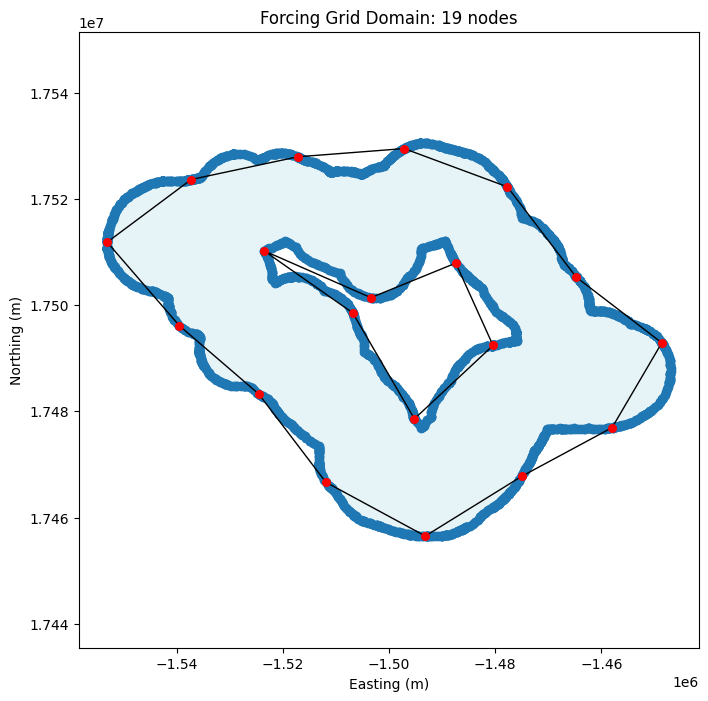

In [4]:
from shapely.plotting import plot_polygon

# Resample polygon with 20 km spacing
Poly_wind_UTM = resample_polygon_iterate(Poly_aera_UTM, 20 * 1000)

# Convert to nodes and edges
node, edge = polygon_to_node_edge(Poly_wind_UTM)

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(Poly_aera_UTM, ax=ax, facecolor='lightblue', alpha=0.3)
for e in edge.astype(int):
    ax.plot(node[e, 0], node[e, 1], 'k-', lw=1)
ax.scatter(node[:, 0], node[:, 1], color='red', s=30, zorder=5)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title(f'Forcing Grid Domain: {len(node)} nodes')
ax.axis('equal');


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          1                 19                 19
          2                 19                 19



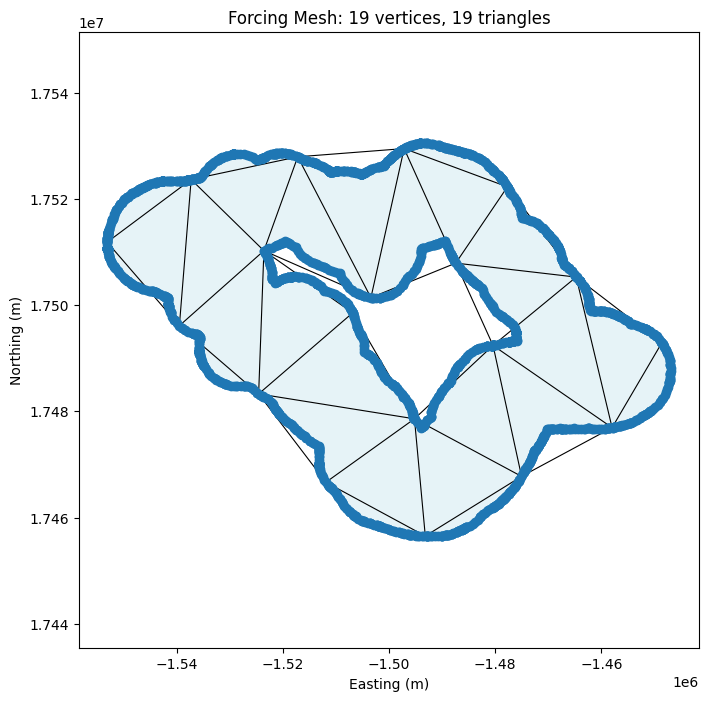

In [27]:
# Generate forcing mesh with Delaunay refinement
vert, etri, tria, tnum = refine(node, edge)

# Visualize
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(Poly_aera_UTM, ax=ax, facecolor='lightblue', alpha=0.3)
ax.triplot(vert[:, 0], vert[:, 1], tria[:, 0:3], color='k', lw=0.8)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title(f'Forcing Mesh: {len(vert)} vertices, {len(tria)} triangles')
ax.axis('equal');

---

## 4. Computational Domain Preparation

Prepare the computational domain with finer resolution:
- Resample indefinite depth polygon at 10 km spacing
- Resample coastline polygon at 500 m spacing (for accurate coastal representation)
- Clean small polygons (islands with < 15 vertices)

In [6]:
# Resample computational domain boundaries
polygone_indef_resampled_UTM = resample_polygon_iterate(
    buffer_area(polygone_indef_UTM, 2).intersection(buffer_area(domain_UTM, -0.01)), 
    10 * 1000
)
polygone_cost_resampled_UTM = resample_polygon_iterate(polygone_cost_UTM, 500)

# Compute intersection
poly_comput_UTM = polygone_indef_resampled_UTM.intersection(polygone_cost_resampled_UTM)

# Clean small polygons
poly_comput_UTM_clean = clean_polygon(poly_comput_UTM, min_vertices=15)

# Convert to nodes and edges
node_c, edge_c = polygon_to_node_edge(poly_comput_UTM)

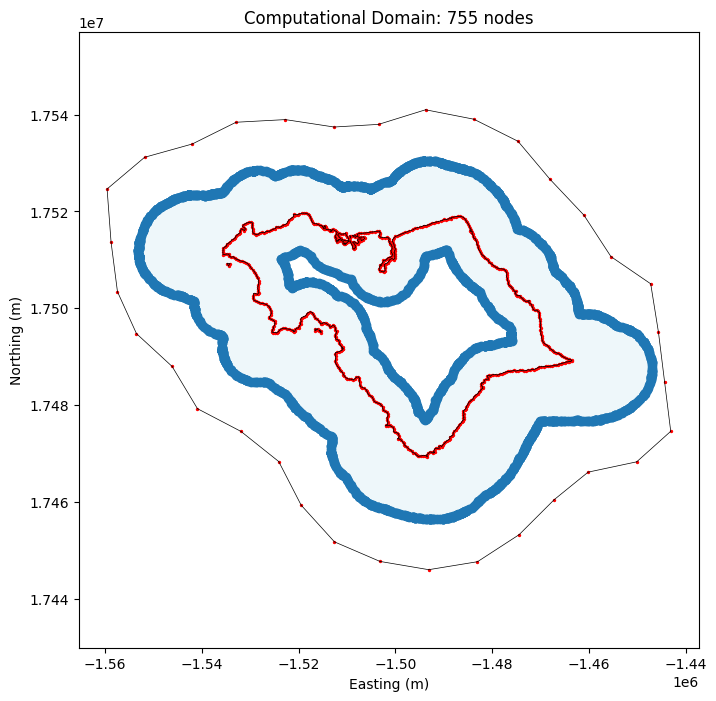

In [7]:
# Visualize computational domain
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(Poly_aera_UTM, ax=ax, facecolor='lightblue', alpha=0.2)

for e in edge_c.astype(int):
    ax.plot(node_c[e, 0], node_c[e, 1], 'k-', lw=0.5)
ax.scatter(node_c[:, 0], node_c[:, 1], color='red', s=2)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title(f'Computational Domain: {len(node_c)} nodes')
ax.axis('equal');

---

## 5. Edge Intersection with Computational Domain

The forcing mesh edges need to be intersected with the computational domain boundary.
This creates the link between the two mesh levels:
- Edges fully inside the computational domain are kept
- Edges crossing the boundary are clipped at the intersection point

In [8]:
# Extract all edges from forcing mesh triangles
edges_new_full = np.vstack([
    tria[:, [0, 1]],
    tria[:, [1, 2]],
    tria[:, [2, 0]]
])
edges_new = np.unique(np.sort(edges_new_full, axis=1), axis=0)

# Check which vertices are inside computational domain
mask_node_in = np.array([poly_comput_UTM.contains(Point(x, y)) for x, y in vert])

# Classify edges by how many endpoints are inside
count_inside = mask_node_in[edges_new].sum(axis=1)
edges_both_inside = edges_new[count_inside == 2]
edges_one_inside = edges_new[count_inside == 1]

In [9]:
# Clip edges at computational domain boundary
edges_one_inside_new = edges_one_inside.copy()
new_points = []

for i, (n1, n2) in enumerate(edges_one_inside):
    p1, p2 = vert[n1], vert[n2]
    inside1 = mask_node_in[n1]
    
    line = LineString([p1, p2])
    inter = line.intersection(buffer_area(poly_comput_UTM, -0.01).boundary)
    
    if inter.is_empty:
        continue
    
    # Handle multiple intersection points
    if inter.geom_type == "MultiPoint":
        points = list(inter.geoms)
        ref = p1 if inside1 else p2
        dists = [Point(ref).distance(pt) for pt in points]
        inter_pt = np.array(points[np.argmin(dists)].coords[0])
    else:
        inter_pt = np.array(inter.coords[0])
    
    new_index = len(vert) + len(new_points)
    new_points.append(inter_pt)
    
    if inside1:
        edges_one_inside_new[i, 1] = new_index
    else:
        edges_one_inside_new[i, 0] = new_index

# Update vertices with new intersection points
if len(new_points) > 0:
    vert_update = np.vstack([vert, np.array(new_points)])

# Clean up: keep only used nodes
edges_used = np.vstack([edges_both_inside, edges_one_inside_new])
used_nodes = np.unique(edges_used.flatten())
vert_clean = vert_update[used_nodes]
mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(used_nodes)}
edges_clean = np.vectorize(mapping.get)(edges_used)

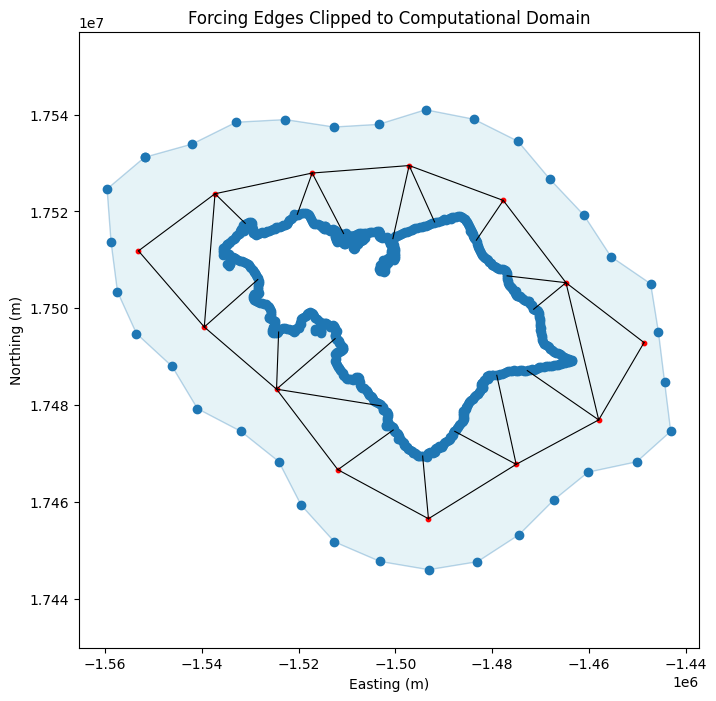

In [10]:
# Visualize clipped forcing edges inside computational domain
fig, ax = plt.subplots(figsize=(8, 8))
plot_polygon(poly_comput_UTM, ax=ax, facecolor='lightblue', alpha=0.3)

for e in edges_clean.astype(int):
    ax.plot(vert_clean[e, 0], vert_clean[e, 1], 'k-', lw=0.8)
ax.scatter(vert_clean[:, 0], vert_clean[:, 1], color='red', s=10)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Forcing Edges Clipped to Computational Domain')
ax.axis('equal');

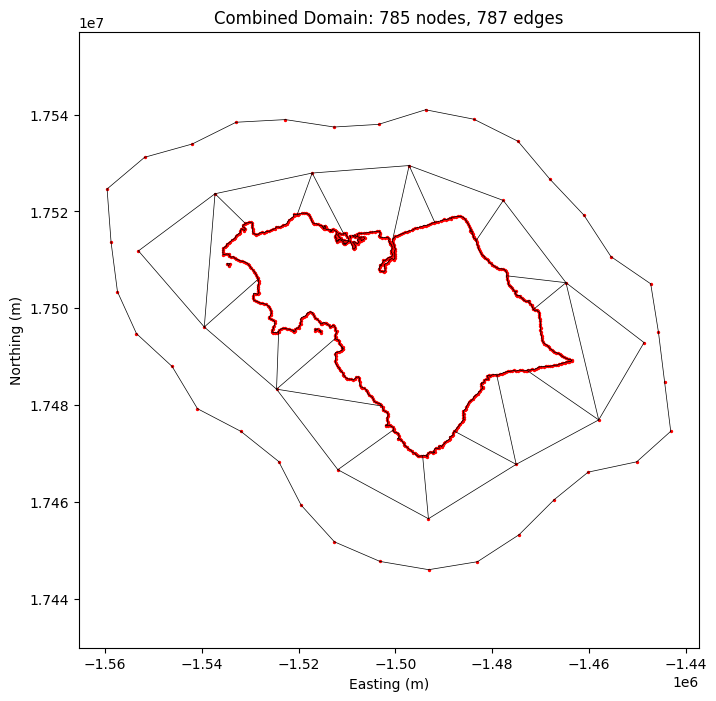

In [11]:
# Combine computational domain boundary with internal forcing edges
part = [np.arange(edge_c.shape[0])]

node_update = np.vstack([node_c, vert_clean])
edge_update = np.vstack([edge_c, edges_clean + len(node_c)])

# Visualize combined edges
fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_update.astype(int):
    ax.plot(node_update[e, 0], node_update[e, 1], 'k-', lw=0.5)
ax.scatter(node_update[:, 0], node_update[:, 1], color='red', s=2)

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title(f'Combined Domain: {len(node_update)} nodes, {len(edge_update)} edges')
ax.axis('equal');

---

## 6. Computational Grid Generation

Generate the refined computational mesh using a **depth-dependent sizing function**.
The mesh element size varies quadratically with depth to ensure adequate resolution in shallow coastal areas.

In [12]:
from pymesh2d.geomesh_util.depth_field import depth_field_from_tif

def hfun_depth_quadratic(test, depth_field, hmin=np.inf):
    """Mesh sizing function based on water depth.
    
    Element size increases quadratically with depth:
    hfun = 0.14 * h^2 + 28 * h + 655
    
    Parameters
    ----------
    test : array
        Test point coordinates (N x 2)
    depth_field : callable or array
        Depth values or interpolation function
    hmin : float
        Minimum element size
    """
    if callable(depth_field):
        h = depth_field(test)
    else:
        h = np.asarray(depth_field)
        if h.size == 1:
            h = np.full(test.shape[0], h)
    
    hfun = np.abs(0.14 * h**2 + 28 * h + 655)
    hfun = np.maximum(hfun, hmin)
    
    return hfun

# Create depth field interpolator
depth_field = depth_field_from_tif(Raster, output_crs=get_utm_crs_from_crs(crs))

def hfun(test):
    return hfun_depth_quadratic(test, depth_field, hmin=500)

In [13]:
# Mesh generation options
opts_refine = {"kind": "delaunay"}
opts_smooth = {"removesmalllinkstrsh": 0.11, "iter": 64}

part = [np.arange(edge_c.shape[0])]

# Generate and smooth computational mesh
vert_c, etri_c, tria_c, tnum_c = refine(node_update, edge_update, part, opts_refine, hfun)

vert_c, etri_c, tria_c, tnum_c = smooth(vert_c, etri_c, tria_c, tnum_c, opts_smooth)


 Refine triangulation...

 -------------------------------------------------------
      |ITER.|          |CDT1(X)|          |CDT2(X)|     
 -------------------------------------------------------
          5                920                903
         10               1045               2445
         20               1169               4901
         21               1170               4924


 Smooth triangulation...

 -------------------------------------------------------
      |ITER.|          |MOVE(X)|          |DTRI(X)|     
 -------------------------------------------------------
          0               1692               4892
          4               1302               4853
          8                158               4849
         12                  7               4853



---

## 7. Mesh Quality Control

### Circumcenter Distance Control for Delft3D FM

For numerical models like **Delft3D FM**, it is essential to control the distance between circumcenters of adjacent triangles.
Small flow links (circumcenters too close together) can cause numerical instabilities in hydrodynamic computations.

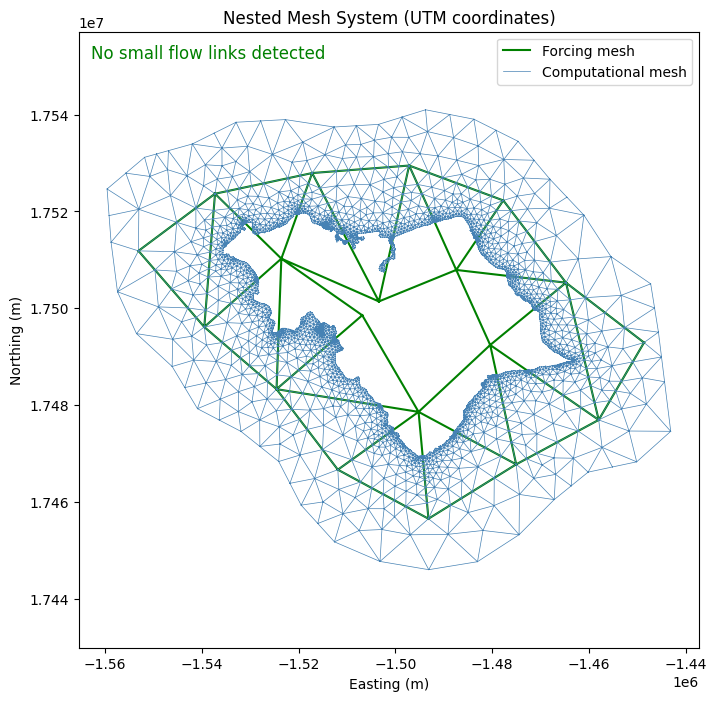

In [14]:
from pymesh2d.mesh_util.tricon import tricon
from pymesh2d.mesh_util.circo import small_flow_centers

# Compute triangle connectivity and identify small flow links
edge_cc, _ = tricon(tria_c, None)

circumcenters, nlinktoosmall = small_flow_centers(
    vert_c, tria_c, edge_cc, 
    removesmalllinkstrsh=0.11, 
    conn=None
)

# Visualize both meshes
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(vert[:, 0], vert[:, 1], tria[:, 0:3], color='green', lw=1.5, label='Forcing mesh')
ax.triplot(vert_c[:, 0], vert_c[:, 1], tria_c[:, 0:3], color='steelblue', lw=0.5, label='Computational mesh')

if nlinktoosmall > 0:
    ax.scatter(circumcenters[:, 0], circumcenters[:, 1], 
               color='red', s=20, alpha=0.7, zorder=5,
               label=f'Small flow links ({nlinktoosmall})')
else:
    ax.text(0.02, 0.98, 'No small flow links detected', 
            transform=ax.transAxes, fontsize=12, color='green',
            verticalalignment='top')

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Nested Mesh System (UTM coordinates)')
ax.legend()
ax.axis('equal');

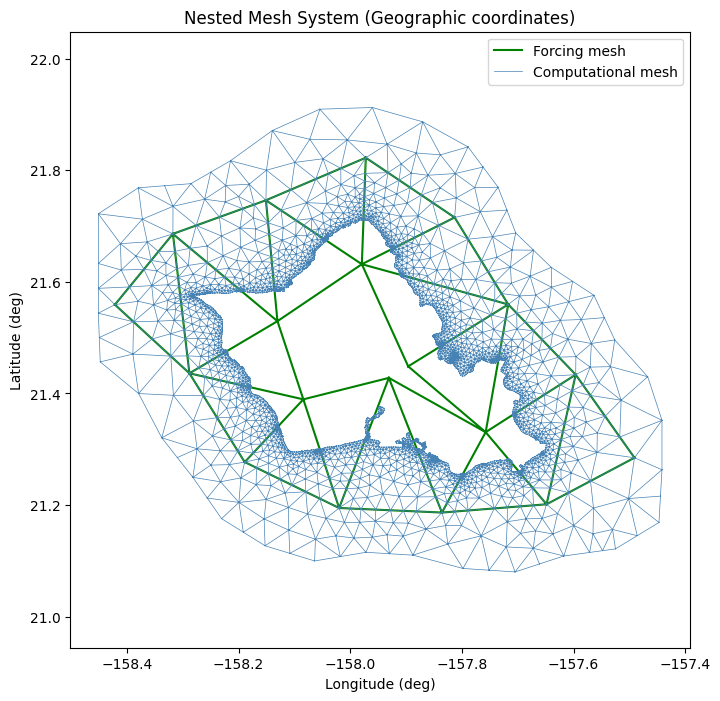

In [15]:
# Reproject to geographic coordinates
vert_geo = reproject_node(vert, get_utm_crs_from_crs(crs), crs)
vert_c_geo = reproject_node(vert_c, get_utm_crs_from_crs(crs), crs)

# Visualize in geographic coordinates
fig, ax = plt.subplots(figsize=(8, 8))

ax.triplot(vert_geo[:, 0], vert_geo[:, 1], tria[:, 0:3], color='green', lw=1.5, label='Forcing mesh')
ax.triplot(vert_c_geo[:, 0], vert_c_geo[:, 1], tria_c[:, 0:3], color='steelblue', lw=0.5, label='Computational mesh')

ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
ax.set_title('Nested Mesh System (Geographic coordinates)')
ax.legend()
ax.axis('equal');

---

## 8. GreenSurge Configuration Export

Export the mesh configuration for **GreenSurge**, a hybrid storm surge model.
The dataset includes:
- Computational and forcing grid geometries
- Discretized wind directions
- Simulation parameters (duration, time step, friction coefficients)

In [16]:
from datetime import datetime

# Simulation parameters
site = "Ohau"
wind_speed = 20                      # m/s
direction_step = 15                  # degrees
simulation_duration_hours = 24       # hours
simulation_time_step_hours = 1/4     # hours (15 min)
forcing_time_step = simulation_time_step_hours

reference_date = [2022, 1, 1, 0, 0, 0]
reference_date_dt = datetime(*reference_date)

Eddy = 10    # Eddy viscosity (m2/s)
Chezy = 70   # Chezy coefficient

In [17]:
import xarray as xr

def build_greensurge_infos_dataset(
    Nodes_calc, Elmts_calc, Nodes_forz, Elmts_forz,
    site, wind_speed, direction_step,
    simulation_duration_hours, simulation_time_step_hours,
    forcing_time_step, reference_date_dt, Eddy, Chezy
):
    """Build a structured dataset for GreenSurge hybrid modeling.
    
    Parameters
    ----------
    Nodes_calc : array
        Computational mesh vertices (lon, lat)
    Elmts_calc : array
        Computational mesh triangles
    Nodes_forz : array
        Forcing mesh vertices (lon, lat)
    Elmts_forz : array
        Forcing mesh triangles
    site : str
        Study site name
    wind_speed : float
        Wind speed for each direction (m/s)
    direction_step : float
        Wind direction discretization step (degrees)
    simulation_duration_hours : float
        Total simulation duration (hours)
    simulation_time_step_hours : float
        Simulation time step (hours)
    forcing_time_step : float
        Forcing data time step (hours)
    reference_date_dt : datetime
        Reference date for simulation
    Eddy : float
        Eddy viscosity (m2/s)
    Chezy : float
        Chezy friction coefficient
    
    Returns
    -------
    xr.Dataset
        Structured dataset for GreenSurge
    """
    num_elements = Elmts_forz.shape[0]
    num_directions = int(360 / direction_step)
    wind_directions = np.arange(0, 360, direction_step)
    reference_date_str = reference_date_dt.strftime("%Y-%m-%d %H:%M:%S")
    
    time_forcing_index = [
        0, forcing_time_step, forcing_time_step + 0.001,
        simulation_duration_hours - 1
    ]
    
    ds = xr.Dataset(
        coords=dict(
            wind_direction_index=("wind_direction_index", np.arange(num_directions)),
            time_forcing_index=("time_forcing_index", time_forcing_index),
            node_computation_longitude=("node_cumputation_index", Nodes_calc[:, 0]),
            node_computation_latitude=("node_cumputation_index", Nodes_calc[:, 1]),
            triangle_nodes=("triangle_forcing_nodes", np.arange(3)),
            node_forcing_index=("node_forcing_index", np.arange(len(Nodes_forz))),
            element_forcing_index=("element_forcing_index", np.arange(num_elements)),
            node_cumputation_index=("node_cumputation_index", np.arange(len(Nodes_calc))),
            element_computation_index=("element_computation_index", np.arange(len(Elmts_calc))),
        ),
        data_vars=dict(
            triangle_computation_connectivity=(
                ("element_computation_index", "triangle_forcing_nodes"),
                Elmts_calc.astype(int),
                {"description": "Computational mesh triangle connectivity"}
            ),
            node_forcing_longitude=(
                "node_forcing_index", Nodes_forz[:, 0],
                {"units": "degrees_east", "description": "Forcing mesh node longitude"}
            ),
            node_forcing_latitude=(
                "node_forcing_index", Nodes_forz[:, 1],
                {"units": "degrees_north", "description": "Forcing mesh node latitude"}
            ),
            triangle_forcing_connectivity=(
                ("element_forcing_index", "triangle_forcing_nodes"),
                Elmts_forz.astype(int),
                {"description": "Forcing mesh triangle connectivity"}
            ),
            wind_directions=(
                "wind_direction_index", wind_directions,
                {"units": "degrees", "description": "Discretized wind directions"}
            ),
            total_elements=((), num_elements, {"description": "Number of forcing elements"}),
            simulation_duration_hours=((), simulation_duration_hours, {"units": "hours"}),
            time_step_hours=((), simulation_time_step_hours, {"units": "hours"}),
            wind_speed=((), wind_speed, {"units": "m/s"}),
            location_name=((), site),
            eddy_viscosity=((), Eddy, {"units": "m2/s"}),
            chezy_coefficient=((), Chezy),
            reference_date=((), reference_date_str),
            forcing_time_step=((), forcing_time_step, {"units": "hour"}),
        ),
        attrs={
            "title": "GreenSurge Simulation Input Dataset",
            "institution": "GeoOcean",
            "model": "GreenSurge",
            "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        }
    )
    
    # Add coordinate attributes
    ds["time_forcing_index"].attrs = {
        "standard_name": "time",
        "units": f"hours since {reference_date_str} +00:00",
        "calendar": "gregorian",
    }
    ds["node_computation_longitude"].attrs = {
        "standard_name": "longitude", "units": "degrees_east"
    }
    ds["node_computation_latitude"].attrs = {
        "standard_name": "latitude", "units": "degrees_north"
    }
    
    return ds

(<Figure size 1000x1000 with 1 Axes>,
 <GeoAxes: title={'center': 'GreenSurge Mesh Setup'}>)

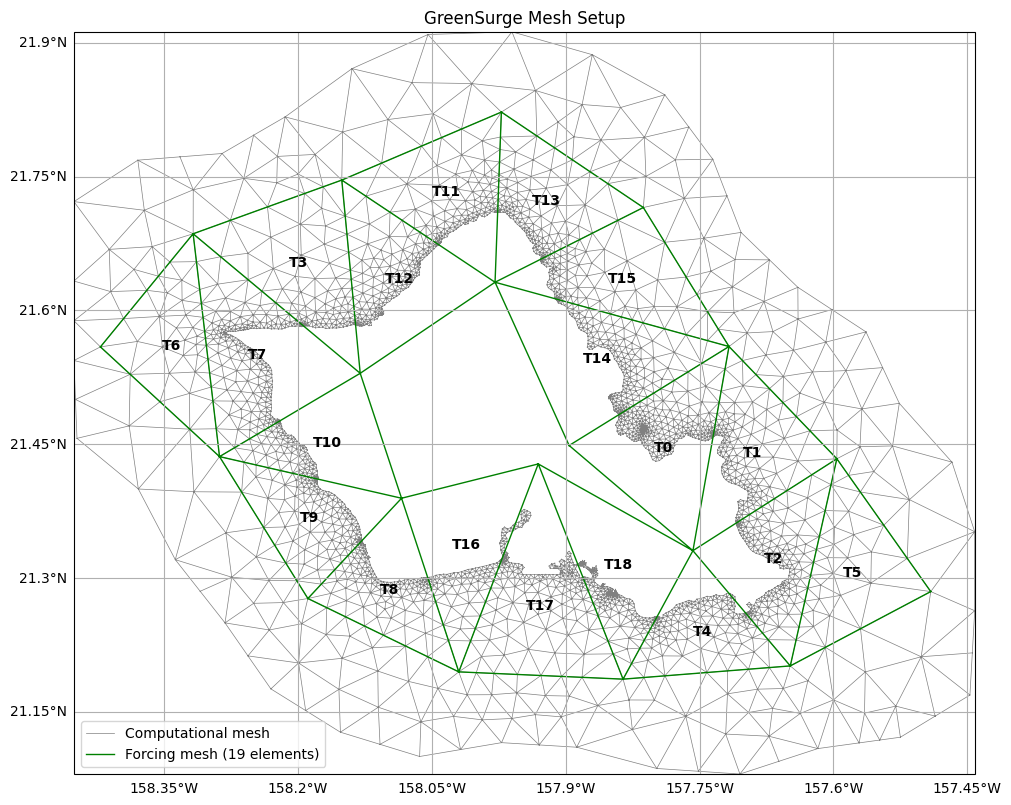

In [18]:
# Build GreenSurge dataset
simulation_dataset = build_greensurge_infos_dataset(
    Nodes_calc=vert_c_geo,
    Elmts_calc=tria_c,
    Nodes_forz=vert_geo,
    Elmts_forz=tria,
    site=site,
    wind_speed=wind_speed,
    direction_step=direction_step,
    simulation_duration_hours=simulation_duration_hours,
    simulation_time_step_hours=simulation_time_step_hours,
    forcing_time_step=forcing_time_step,
    reference_date_dt=reference_date_dt,
    Eddy=Eddy,
    Chezy=Chezy,
)

# Visualize setup
from bluemath_tk.additive.greensurge import plot_greensurge_setup
plot_greensurge_setup(info_ds=simulation_dataset)

In [19]:
# Export to NetCDF
output_file = f"inputs/GreenSurge_{site}_info.nc"
simulation_dataset.to_netcdf(output_file, "w", "NETCDF3_CLASSIC")

simulation_dataset

<xarray.Dataset> Size: 226kB
Dimensions:                            (element_computation_index: 4853,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 19,
                                        element_forcing_index: 19,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 2861)
Coordinates:
  * element_computation_index          (element_computation_index) int64 39kB ...
  * node_forcing_index                 (node_forcing_index) int64 152B 0 ... 18
  * element_forcing_index              (element_forcing_index) int64 152B 0 ....
  * wind_direction_index               (wind_direction_index) int64 192B 0 .....
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int64 23kB 0 ...
    node_computation_longitude         (node_cumputation_index) float64 23kB ...
    node_computation_latitude          (node_cumputation_index) float64 23kB ...
    triangle_nodes                     (triangle_forcing_nodes) int64 24B 0 1 2
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int64 116kB ...
    node_forcing_longitude             (node_forcing_index) float64 152B -157...
    node_forcing_latitude              (node_forcing_index) float64 152B 21.2...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int64 456B ...
    wind_directions                    (wind_direction_index) int64 192B 0 .....
    total_elements                     int64 8B 19
    ...                                 ...
    wind_speed                         int64 8B 20
    location_name                      <U4 16B 'Ohau'
    eddy_viscosity                     int64 8B 10
    chezy_coefficient                  int64 8B 70
    reference_date                     <U19 76B '2022-01-01 00:00:00'
    forcing_time_step                  float64 8B 0.25
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2025-12-04 17:40:38

---

## 9. Grid Export for Delft3D FM

Export the computational mesh in formats compatible with **Delft3D FM**:
- NetCDF format (ADCIRC-style 2DM)
- GRD format with boundary classification

In [20]:
from pymesh2d.geomesh_util.interpolation_mesh import interpolate_from_tiff

# Interpolate bathymetry onto mesh vertices
z = interpolate_from_tiff(Raster, vert_c_geo, crs)

In [21]:
from pymesh2d.geomesh_util.grd_util import adcirc2DFlowFM

# Export to NetCDF format
adcirc2DFlowFM(np.column_stack((vert_c_geo, z)), tria_c, "templates/mesh_Ohau_net.nc")

In [22]:
from pymesh2d.geomesh_util.border_util import identify_boundary

# Identify boundary types (open ocean vs land)
edge_tag, edge_open, edge_land = identify_boundary(vert_c_geo, tria_c, z, zlim=15)

In [23]:
from pymesh2d.geomesh_util.grd_util import export_to_grd

# Export to GRD format with boundaries
export_to_grd(
    "outputs/GEBCO_grid.grd",
    vert=vert_c_geo,
    tria=tria_c,
    z=z,
    crs=crs,
    edge_tag=edge_tag,
    edge_open=edge_open,
    edge_land=edge_land,
)

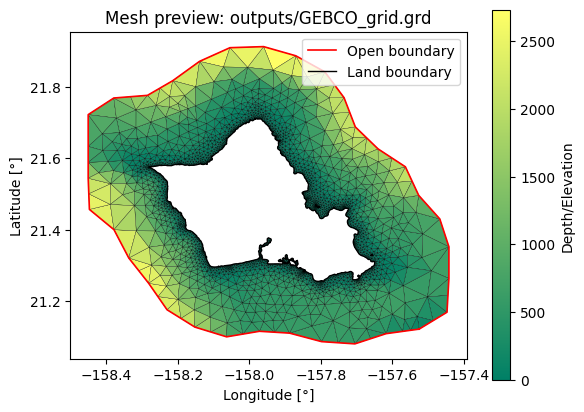

In [24]:
from pymesh2d.geomesh_util.grd_util import plot_grd

# Visualize final grid with boundary classification
plot_grd("outputs/GEBCO_grid.grd", show_boundaries=True)

---

## 10. Boundary Conditions Setup

Generate boundary condition files for Delft3D FM:
- `.pli` file: Polyline defining boundary locations
- `.bc` file: Boundary condition time series (Riemann invariants)
- `.ext` file: External forcing configuration

In [28]:
# Create buffered boundary points (slightly outside the mesh)
edge_open_closed = np.vstack([edge_open, edge_open[0]])

# Compute edge midpoints
X = np.mean(vert_c_geo[edge_open_closed, 0], axis=1)
Y = np.mean(vert_c_geo[edge_open_closed, 1], axis=1)
coords = np.column_stack([X, Y])

# Compute centroid and outward vectors
cx, cy = coords.mean(axis=0)
vecs = coords - np.array([cx, cy])
vecs_unit = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)

# Buffer outward by 0.05 degrees
d = 0.05
coords_buffer = coords + d * vecs_unit
Xb, Yb = coords_buffer[:, 0], coords_buffer[:, 1]

In [29]:
# Boundary file parameters
pli = "Boundary01"
bc = "Riemann"
ext = "FlowFM_bnd"
output_path = "templates"

# Write .pli and .bc files
with open(f"{output_path}/{pli}.pli", 'w') as file_pli, \
     open(f"{output_path}/{bc}.bc", 'w') as file_bc:
    
    file_pli.write(f"{pli}\n")
    N = len(Xb)
    file_pli.write(f"    {N}    2\n")
    
    for i, (xi, yi) in enumerate(zip(Xb, Yb), start=1):
        boundary_id = f"{pli}_{i:04d}"
        file_pli.write(f"{xi:.15E}  {yi:.15E} {boundary_id}\n")
        
        file_bc.write("[forcing]\n")
        file_bc.write(f"Name = {boundary_id}\n")
        file_bc.write("Function = timeseries\n")
        file_bc.write("Time-interpolation = linear\n")
        file_bc.write("Quantity = time\n")
        file_bc.write("Unit = seconds since 2000-01-01 00:00:00\n")
        file_bc.write("Quantity = riemannbnd\n")
        file_bc.write("Unit = m\n")
        file_bc.write("0    0\n")
        file_bc.write("9999999999   0\n\n")

# Write .ext file
with open(f"{output_path}/{ext}.ext", 'w') as file:
    file.write("[general]\n")
    file.write("fileVersion=2.01\n")
    file.write("fileType=extForce\n\n")
    file.write("[boundary]\n")
    file.write("quantity=riemannbnd\n")
    file.write(f"locationFile={pli}.pli\n")
    file.write(f"forcingFile={bc}.bc\n")

---

### References

- **pymesh2D Repository**: [https://github.com/GeoOcean/pymesh2d](https://github.com/GeoOcean/pymesh2d)
- **GreenSurge**: Hybrid storm surge model - GeoOcean Research Group - [https://doi.org/10.1016/j.coastaleng.2024.104691](https://doi.org/10.1016/j.coastaleng.2024.104691)
- **Delft3D FM**: [https://www.deltares.nl/en/software/delft3d-flexible-mesh-suite](https://www.deltares.nl/en/software/delft3d-flexible-mesh-suite)